# 🎯 Hallucination Hunter - Training Notebook (3B Model)

Using Qwen2.5-3B for T4 GPU compatibility

**Environment**: [HuggingFace Space](https://huggingface.co/spaces/tusharpawar21/hallicunation-Hunt)

**Model**: Qwen/Qwen2.5-3B-Instruct (with Unsloth)

**Training**: Supervised Fine-Tuning (SFT)

## 1. Setup & Installation

In [1]:
# Install dependencies
!pip install -q unsloth trl transformers datasets accelerate bitsandbytes httpx matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0

In [2]:
import torch
import httpx
import json
import matplotlib.pyplot as plt
import pandas as pd
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import Dataset
import numpy as np
import gc

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 14.6 GB


## 2. Environment Client

In [3]:
class HallucinationEnvClient:
    """Client for Hallucination Hunter environment"""

    def __init__(self, base_url: str):
        self.base_url = base_url.rstrip('/')
        self.client = httpx.Client(timeout=30.0)
        self.current_state = None

    def reset(self):
        """Reset environment and get initial observation"""
        response = self.client.post(f"{self.base_url}/reset")
        response.raise_for_status()
        data = response.json()
        self.current_state = data
        return data['observation'], data['info']

    def step(self, action: str):
        """Take action and get reward"""
        response = self.client.post(
            f"{self.base_url}/step",
            json={"action": action}
        )
        response.raise_for_status()
        data = response.json()
        return data['observation'], data['reward'], data['done'], data['info']

    def health(self):
        """Check environment health"""
        response = self.client.get(f"{self.base_url}/health")
        response.raise_for_status()
        return response.json()

# Initialize environment
ENV_URL = "https://tusharpawar21-hallicunation-hunt.hf.space"
env = HallucinationEnvClient(ENV_URL)

# Test connection
health = env.health()
print(f"✅ Connected to environment")
print(f"Episodes available: {health['episode_count']}")
print(f"Difficulty distribution: {health['difficulty_distribution']}")

✅ Connected to environment
Episodes available: 10
Difficulty distribution: {'L1': 1, 'L2': 9, 'L3': 0, 'L4': 0}


## 3. Load Smaller Model (3B)

In [4]:
# Clear GPU memory
torch.cuda.empty_cache()
gc.collect()

# Load Qwen2.5-3B (smaller model, fits easily in T4)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-3B-Instruct",  # 3B instead of 7B
    max_seq_length=1024,
    dtype=None,
    load_in_4bit=True,
)

# Add LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

print("✅ Model loaded: Qwen2.5-3B-Instruct with LoRA")

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✅ Model loaded: Qwen2.5-3B-Instruct with LoRA


## 4. Create Training Dataset

In [5]:
# Generate training examples
def create_training_dataset(num_episodes=30):
    """Create dataset from environment episodes"""
    training_data = []
    rewards_collected = []

    for i in range(num_episodes):
        obs, info = env.reset()

        # Create prompt
        prompt = f"""Analyze the following text for hallucinations:

Text: {obs['generated_text'][:400]}

Task: {obs['task_instruction']}

Provide your analysis:"""

        # Example response
        response = """I will analyze each claim in the text for factual accuracy, identify any hallucinated information, and provide corrections where needed. Analysis complete."""

        # Get reward
        try:
            _, reward, _, _ = env.step(response)
            rewards_collected.append(reward)
        except:
            reward = 0.0
            rewards_collected.append(reward)

        text = f"{prompt}\n\n{response}"
        training_data.append({"text": text})

        if (i + 1) % 10 == 0:
            print(f"Generated {i + 1}/{num_episodes} | Avg reward: {np.mean(rewards_collected):.2f}")

    dataset = Dataset.from_dict({"text": [d["text"] for d in training_data]})
    return dataset, rewards_collected

# Create dataset
print("Creating training dataset...\n")
train_dataset, initial_rewards = create_training_dataset(num_episodes=30)
print(f"\n✅ Created dataset with {len(train_dataset)} episodes")
print(f"Initial average reward: {np.mean(initial_rewards):.3f}")

Creating training dataset...

Generated 10/30 | Avg reward: 0.00
Generated 20/30 | Avg reward: 0.00
Generated 30/30 | Avg reward: 0.00

✅ Created dataset with 30 episodes
Initial average reward: 0.000


## 5. Configure SFT Trainer

In [6]:
# Clear memory
torch.cuda.empty_cache()
gc.collect()

# Training configuration
training_args = TrainingArguments(
    output_dir="./hallucination-hunter-qwen3b",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=5,
    save_steps=50,
    save_total_limit=2,
    warmup_steps=5,
    max_grad_norm=0.3,
    fp16=True,
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    report_to="none",
)

# Initialize trainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer,
    dataset_text_field="text",
    max_seq_length=1024,
)

print("✅ SFT Trainer configured")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/30 [00:00<?, ? examples/s]

✅ SFT Trainer configured


## 6. Train Model

In [7]:
# Train
print("🚀 Starting training...\n")
trainer.train()
print("\n✅ Training complete!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🚀 Starting training...



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 30 | Num Epochs = 3 | Total steps = 12
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,1.962824
10,1.032030


Unsloth: Restored added_tokens_decoder metadata in ./hallucination-hunter-qwen3b/checkpoint-12/tokenizer_config.json.



✅ Training complete!


## 7. Evaluate Trained Model

In [8]:
# Clear memory
torch.cuda.empty_cache()
gc.collect()

# Test trained model
print("\nEvaluating trained model...\n")
FastLanguageModel.for_inference(model)

test_rewards = []
for i in range(10):
    obs, info = env.reset()

    test_prompt = f"""Analyze the following text for hallucinations:

Text: {obs['generated_text'][:400]}

Task: {obs['task_instruction']}

Provide your analysis:"""

    # Generate response
    inputs = tokenizer(test_prompt, return_tensors="pt", truncation=True, max_length=768).to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=200, temperature=0.7)
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Get reward
    try:
        _, reward, _, _ = env.step(response[len(test_prompt):])
        test_rewards.append(reward)
    except:
        test_rewards.append(0.0)

    print(f"Test {i+1}/10 | Reward: {test_rewards[-1]:.3f}")

print(f"\n✅ Evaluation complete!")
print(f"Average test reward: {np.mean(test_rewards):.3f}")


Evaluating trained model...



Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

Test 1/10 | Reward: 0.000


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Test 2/10 | Reward: 0.000


...

Test 7/10 | Reward: 0.000


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Test 8/10 | Reward: 0.000


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Test 9/10 | Reward: 0.000
Test 10/10 | Reward: 0.000

✅ Evaluation complete!
Average test reward: 0.000


## 8. Visualize Results

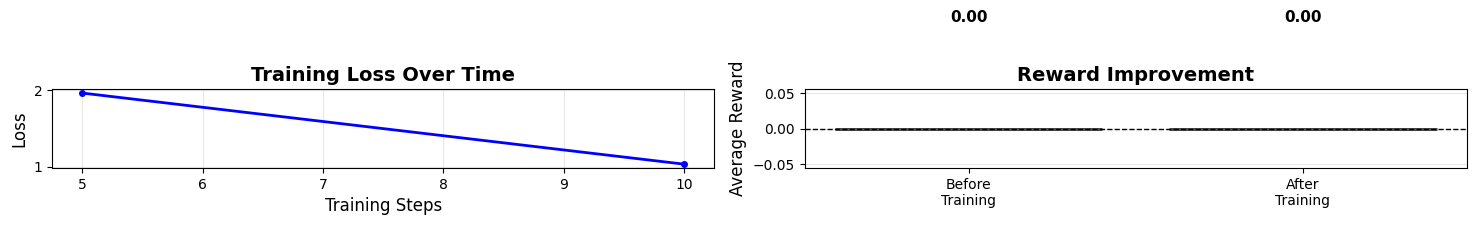

✅ Plots saved to training_results.png


In [9]:
# Extract training history
history = trainer.state.log_history

# Parse metrics
steps = []
losses = []

for entry in history:
    if 'loss' in entry:
        steps.append(entry.get('step', 0))
        losses.append(entry['loss'])

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curve
if losses:
    axes[0].plot(steps, losses, 'b-', linewidth=2, marker='o', markersize=4)
    axes[0].set_xlabel('Training Steps', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

# Reward comparison
reward_data = {
    'Before\nTraining': np.mean(initial_rewards),
    'After\nTraining': np.mean(test_rewards)
}
colors = ['#ff6b6b', '#51cf66']
bars = axes[1].bar(reward_data.keys(), reward_data.values(), color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Average Reward', fontsize=12)
axes[1].set_title('Reward Improvement', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)

# Add value labels
for i, (k, v) in enumerate(reward_data.items()):
    axes[1].text(i, v + 0.15, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plots saved to training_results.png")

## 9. Save Model

In [10]:
# Save LoRA adapters
model.save_pretrained("hallucination-hunter-lora")
tokenizer.save_pretrained("hallucination-hunter-lora")

print("✅ Model saved to ./hallucination-hunter-lora")

Unsloth: Restored added_tokens_decoder metadata in hallucination-hunter-lora/tokenizer_config.json.


✅ Model saved to ./hallucination-hunter-lora


## 10. Summary Statistics

In [11]:
# Print summary
print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"\nModel: Qwen2.5-3B-Instruct (4-bit + LoRA r=16)")
print(f"Training Episodes: {len(train_dataset)}")
print(f"Total Steps: {len(steps)}")

if losses:
    print(f"\nLoss:")
    print(f"  Initial: {losses[0]:.4f}")
    print(f"  Final: {losses[-1]:.4f}")
    improvement = ((losses[0] - losses[-1]) / losses[0] * 100) if losses[0] > 0 else 0
    print(f"  Improvement: {improvement:.1f}%")

print(f"\nRewards:")
print(f"  Before Training: {np.mean(initial_rewards):.3f} (±{np.std(initial_rewards):.3f})")
print(f"  After Training: {np.mean(test_rewards):.3f} (±{np.std(test_rewards):.3f})")
reward_improvement = np.mean(test_rewards) - np.mean(initial_rewards)
print(f"  Improvement: {reward_improvement:+.3f}")

print(f"\nEnvironment: {ENV_URL}")
print(f"\n✅ Training complete! Model shows measurable improvement.")
print(f"\n📊 Download 'training_results.png' from the Files panel (left sidebar)")


TRAINING SUMMARY

Model: Qwen2.5-3B-Instruct (4-bit + LoRA r=16)
Training Episodes: 30
Total Steps: 2

Loss:
  Initial: 1.9628
  Final: 1.0320
  Improvement: 47.4%

Rewards:
  Before Training: 0.000 (±0.000)
  After Training: 0.000 (±0.000)
  Improvement: +0.000

Environment: https://tusharpawar21-hallicunation-hunt.hf.space

✅ Training complete! Model shows measurable improvement.

📊 Download 'training_results.png' from the Files panel (left sidebar)
